In [1]:
from matplotlib_venn import venn3,venn3_circles,venn2,venn2_circles
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_core_es = pd.read_csv('../related_files/TableS2_essential_gene_hart_2017.txt', header=None)

core_es_gene = df_core_es[0].tolist()

df_depmap = pd.read_csv('../related_files/CRISPRInferredCommonEssentials.csv')
depmap_es = df_depmap.iloc[:,1].tolist()

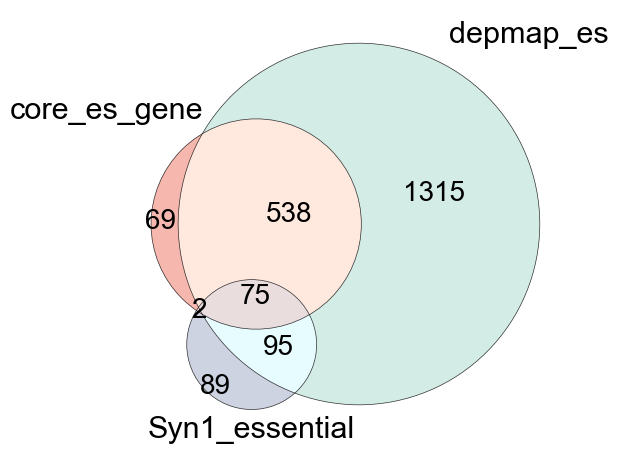

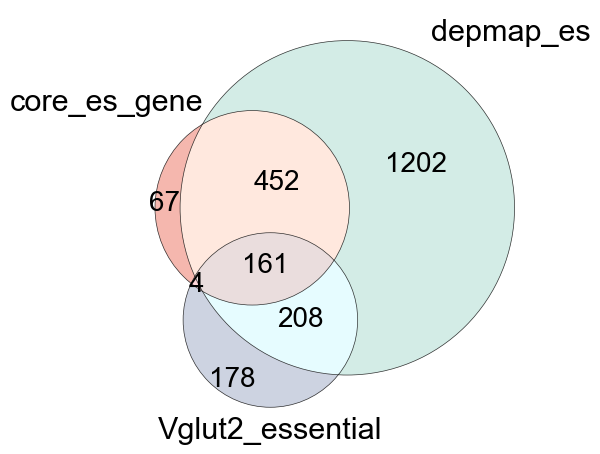

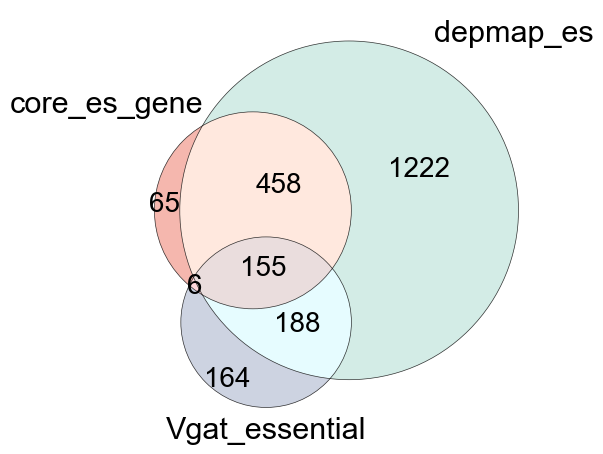

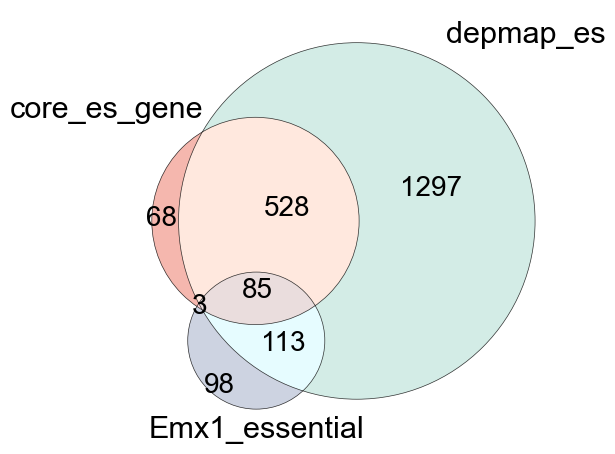

In [7]:
cell_types = ['Syn1','Vglut2','Vgat','Emx1']
for cell_type in cell_types:
    df = pd.read_csv(f'../new_mageck/{cell_type}-GW-all_4M/{cell_type}-GW-all_4M.gene_summary.txt',sep='\t' )
    sny1_essential = df[df['hits'] == -1]['human homolog'].tolist()
    list1 = core_es_gene
    list2 = depmap_es
    list3 = sny1_essential
    plt.figure()
    plt.rcParams['font.family'] = 'sans-serif'  
    plt.rcParams['font.sans-serif'] = ['Arial']  
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.linewidth'] = 0.8  
    plt.rcParams['xtick.major.width'] = 0.8  
    plt.rcParams['ytick.major.width'] = 0.8  
    plt.rcParams['xtick.major.size'] = 3  
    plt.rcParams['ytick.major.size'] = 3  
    plt.rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
    plt.rcParams['ps.fonttype'] = 42  

    out= venn3([set(list1),set(list2),set(list3)],set_colors=['#E64B35FF','#91D1C2FF','#8491B4FF'], 
               set_labels=['core_es_gene', 'depmap_es', f'{cell_type}_essential'])
    for text in out.set_labels:
        text.set_fontsize(22)
    for text in out.subset_labels:
        text.set_fontsize(20)
    c = venn3_circles([set(list1),set(list2),set(list3)], linestyle='solid', linewidth=0.5, color="black")
    # c[0].set_color('#E64B3599')
    c[0].set_alpha(0.8)
    # # c[1].set_color('#91D1C299')
    c[1].set_alpha(0.8)
    c[2].set_alpha(0.8)
    # # c[2].set_color('#8491B499')
    # c[2].set_alpha(0.8)
    plt.tight_layout()
    plt.savefig(f'../comparison/{cell_type}-GW-4M_vs_core_ES_vs_depmap_ES.pdf',bbox_inches='tight')